# Adding roads to the graph

In [1]:
import sys
sys.path.append('..')
import geopandas as gpd

## Initialization

In [11]:
local_crs = 32637

The graph can be obtained by ``transport_frames.graph.get_graph_from_polygon()``

In [2]:
import pickle

with open("graph.pkl", "rb") as f:
    graph = pickle.load(f)

Load a file with the roads to add. They must contain ``ref_type`` and ``reg`` parameter 

In [3]:
with open("new_roads.pkl", "rb") as f:
    new_roads = pickle.load(f)
    
new_roads

,length_meter,type,time_sec,time_min,highway,maxspeed,reg,ref,is_exit,node_start,node_end,ref_type,geometry
0,314159.265359,car,None,None,None,None,1,None,None,None,None,1.2,"LINESTRING (456400.816 5971764.699, 456300.150..."


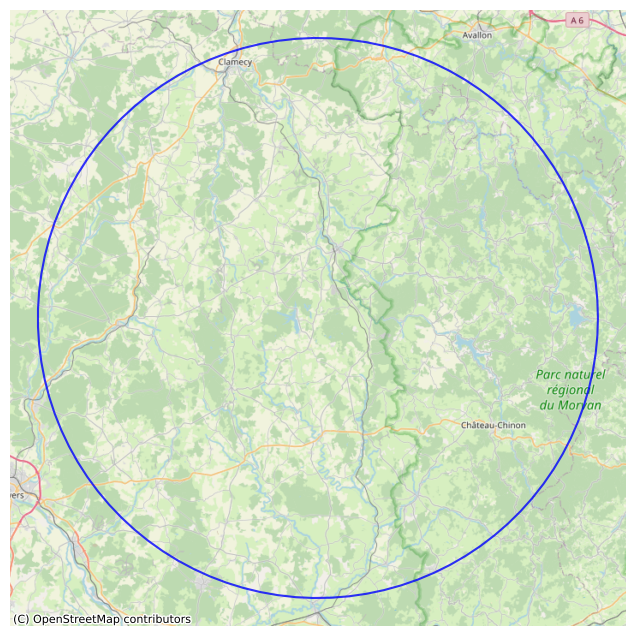

In [6]:
from transport_frames.utils.helper_funcs import plot_graph

plot_graph(edges=new_roads)

## Road addition

In [14]:
from transport_frames.road_adder import add_roads

bigger_graph = add_roads(graph,new_roads,local_crs)

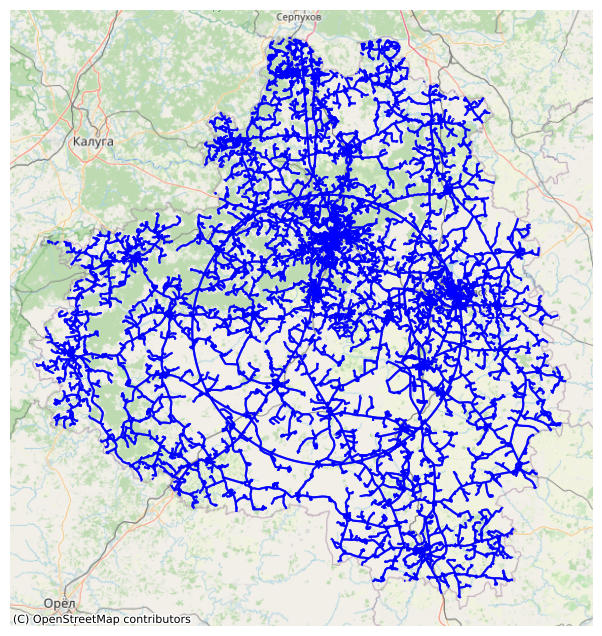

In [16]:
plot_graph(bigger_graph)

## Check connectivity improvement

In [7]:
settlement_points = gpd.read_file('/Users/polina/Desktop/github/transport_frames/data/Тульская_область/Тульская_область_region_points.geojson')
settlement_polygons = gpd.read_file('/Users/polina/Desktop/github/transport_frames/data/Тульская_область/settlement.geojson')

In [ ]:
from transport_frames.indicators import indicator_connectivity_drive

con_old = indicator_connectivity_drive(settlement_points,settlement_polygons,local_crs,drive_graph = graph)
con_old.head()

,name,geometry,connectivity
0,Манаенское,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",132.3375
1,Астаповское,"POLYGON ((36.47061 53.63576, 36.48947 53.63114...",119.3350
2,Арсеньево,"POLYGON ((36.63005 53.72754, 36.63174 53.72702...",111.7100
3,Левобережное,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",154.5850
4,Правобережное,"POLYGON ((36.14550 53.80533, 36.14561 53.80468...",144.0700


In [ ]:
con_new = indicator_connectivity_drive(settlement_points,settlement_polygons,local_crs,drive_graph = bigger_graph)
con_new.head()

,name,geometry,connectivity
0,Манаенское,"POLYGON ((36.27046 53.67571, 36.27343 53.67505...",111.3775
1,Астаповское,"POLYGON ((36.47061 53.63576, 36.48947 53.63114...",90.1800
2,Арсеньево,"POLYGON ((36.63005 53.72754, 36.63174 53.72702...",81.6700
3,Левобережное,"POLYGON ((35.89856 53.85018, 35.90015 53.84679...",127.6400
4,Правобережное,"POLYGON ((36.14550 53.80533, 36.14561 53.80468...",117.0225
